In [1]:
from mdcrow import MDCrow
from langchain.callbacks import get_openai_callback
from datetime import datetime
import os 
import traceback

In [2]:
import sys
parent_dir = os.path.abspath(os.path.join(os.getcwd(), '../'))
sys.path.append(parent_dir)
from robustness_prompts import get_prompt # noqa: E402

prompt_7_natural = get_prompt("natural", 7)

prompt_7_natural

'Simulate 1LYZ for 1ps at 300 K. Report the secondary structure assignments of the downloaded PDB structure and any known binding or active sites. Compute the RMSD, SASA, and radius of gyration of the simulation.'

In [3]:
llm_model = "gpt-4-1106-preview"
tools = "all"

In [4]:
agent = MDCrow(
    agent_type="Structured", 
    model=llm_model, 
    top_k_tools=tools, 
    use_memory=False,
    streaming=False,
    verbose=True,
)
with get_openai_callback() as cb:
    chat_start = datetime.now()
    try:
        response = agent.run(prompt_7_natural, callbacks=[cb])
        print(response)
    except Exception as e:
        exc_type, exc_value, exc_traceback = sys.exc_info()
        print(f'{type(e).__name__}:{e}')
        print("".join(traceback.format_exception(exc_type, exc_value, exc_traceback)))
    chat_end = datetime.now()
    total_runtime = (chat_end - chat_start).total_seconds()
    print(cb)
    print(f"Total runtime: {total_runtime:.2f}s")



> Entering new AgentExecutor chain...


Thought: To address the question, I need to perform several steps. First, I will download the PDB structure of 1LYZ. Then, I will set up and run a molecular dynamics simulation for 1 picosecond at 300 K. After the simulation, I will report the secondary structure assignments of the downloaded PDB structure. I will also look up any known binding or active sites for 1LYZ. Finally, I will compute the RMSD, SASA, and radius of gyration of the simulation. The first step is to download the PDB structure of 1LYZ.

Action:
```
{
    "action": "PDBFileDownloader",
    "action_input": {
        "query": "1LYZ"
    }
}
```
PDB file found with this ID: 1LYZ

Observation: Succeeded. Downloaded the PDB file:1LYZ_213819
Thought:

Now that I have the PDB file for 1LYZ, the next step is to set up and run a molecular dynamics simulation for 1 picosecond at 300 K. I will use the SetUpandRunFunction tool to perform this task. I will specify the PDB ID, the desired temperature, and the simulation time.

Action:
```
{
    "action": "SetUpandRunFunction",
    "action_input": {
        "pdb_id": "1LYZ_213819",
        "forcefield_files": ["amber99sbildn.xml", "tip3p.xml"],
        "system_params": {
            "nonbondedMethod": "PME",
            "nonbondedCutoff": "1 * nanometers",
            "constraints": "HBonds",
            "rigidWater": true,
            "solvate": true
        },
        "integrator_params": {
            "integrator_type": "LangevinMiddle",
            "Temperature": "300 * kelvin",
            "Friction": "1.0 / picoseconds",
            "Timestep": "0.002 * picoseconds"
        },
        "simulation_params": {
            "Ensemble": "NVT",
            "Number of Steps": 500,
            

The previous attempt to run the simulation failed because the constraintTolerance parameter was not specified. I need to correct this by adding the constraintTolerance parameter to the system_params and then rerun the simulation setup.

Action:
```
{
    "action": "SetUpandRunFunction",
    "action_input": {
        "pdb_id": "1LYZ_213819",
        "forcefield_files": ["amber99sbildn.xml", "tip3p.xml"],
        "system_params": {
            "nonbondedMethod": "PME",
            "nonbondedCutoff": "1 * nanometers",
            "constraints": "HBonds",
            "rigidWater": true,
            "constraintTolerance": 0.00001,
            "solvate": true
        },
        "integrator_params": {
            "integrator_type": "LangevinMiddle",
            "Temperature": "300 * kelvin",
            "Friction": "1.0 / picoseconds",
            "Timestep": "0.002 * picoseconds"
        },
        "simulation_params": {
            "Ensemble": "NVT",
            "Number of Steps": 500,
    

About to create system...
Attempts at creating system: 0/3
Error adding solvent ValueError – No template found for residue 1 (LYS).  The set of atoms is similar to HID, but it is missing 8 atoms.  For more information, see https://github.com/openmm/openmm/wiki/Frequently-Asked-Questions#template
Residue code: LYS
Residue code not in solvent list. Adding forcefield                         not supported.

Observation: Failed. No template found for residue 1 (LYS).  The set of atoms is similar to HID, but it is missing 8 atoms.  For more information, see https://github.com/openmm/openmm/wiki/Frequently-Asked-Questions#templateThis were the inputs {'pdb_id': '1LYZ_213819', 'forcefield_files': ['amber99sbildn.xml', 'tip3p.xml'], 'system_params': {'nonbondedMethod': 'PME', 'nonbondedCutoff': '1 * nanometers', 'constraints': 'HBonds', 'rigidWater': True, 'constraintTolerance': 1e-05, 'solvate': True}, 'integrator_params': {'integrator_type': 'LangevinMiddle', 'Temperature': '300 * kelvin', 'F

...

Data saved to /gpfs/fs2/scratch/qcampbe2/repos/MDCrow/ckpt/ckpt_14/records/sasa_sim0_213848.csv
SASA plot saved to FIG_sasa_sim0_213848_20251222_220441.png

Observation: Succeeded. SASA values computed and saved with File ID sasa_sim0_213848. SASA analysis completed. Saved the plot with plot ID fig0_220441. 
Thought:

The SASA computation for the simulation of 1LYZ has been completed. Now, I will compute the radius of gyration using the RadiusofGyrationTool with the initial topology file and the trajectory file from the simulation.

Action:
```
{
    "action": "RadiusofGyrationTool",
    "action_input": {
        "traj_file": "rec0_213853",
        "top_file": "top_sim0_213848"
    }
}
```

plot_name:  FIG_rgy_rec0_213853_20251222_220446.png
plot_path /gpfs/fs2/scratch/qcampbe2/repos/MDCrow/ckpt/ckpt_14/figures/FIG_rgy_rec0_213853_20251222_220446.png

Observation: Succeeded. Radii of gyration saved to /gpfs/fs2/scratch/qcampbe2/repos/MDCrow/ckpt/ckpt_14/figures/radii_of_gyration_rec0_213853.csv with id rgy_rec0_213853.Plot saved as: FIG_rgy_rec0_213853_20251222_220446.png with plot ID fig0_220446Average radius of gyration: 3.44 nm
Thought:

I have completed the simulation of 1LYZ for 1 picosecond at 300 K and obtained the secondary structure assignments, known active sites, RMSD, SASA, and radius of gyration. The secondary structure consists of 7714 residues in helices, 1862 residues in strands, and 9774 residues in coils. Active sites were identified at residues 53 and 71. The RMSD values are saved with file ID rmsd_213848, and the SASA values are saved with File ID sasa_sim0_213848. The average radius of gyration is 3.44 nm. No known binding sites were found for 1LYZ.

Action:
```
{
  "action": "Final Answer",
  "action_input": "Simulation of 1LYZ for 1 picosecond at 300 K completed. Secondary structure assignments: 7714 residues in helices, 1862 residues in strands, 9774 residues in coils. Active sites at residues 53 and 71. RMSD values saved with file ID rmsd_213848. SASA values saved with File ID sasa_sim0_213848. Average radius of gyration: 3.44 nm. No known binding sites found for 1LYZ."
}
```

> Finished chain.
({

<Figure size 640x480 with 0 Axes>

In [3]:
registry = agent.path_registry
print(registry.list_path_names_and_descriptions().replace(",", "\n"))

Files found in registry: 1LYZ_213819: PDB file downloaded from RSCB
 PDBFile ID: 1LYZ_213819
 1LYZ_213841: Cleaned File:  Removed Heterogens
 and Water Removed.  Replaced Nonstandard Residues. Added Hydrogens at pH 7.0. Missing Atoms added and nonstandard residues replaced. 
 top_sim0_213848: Initial positions for simulation sim0_213848
 sim0_213848: Basic Simulation of Protein 1LYZ_213841
 rec0_213853: Simulation trajectory for protein 1LYZ_213841 and simulation sim0_213848
 rec1_213853: Simulation state log for protein 1LYZ_213841 and simulation sim0_213848
 rec2_213853: Simulation pdb frames for protein 1LYZ_213841 and simulation sim0_213848
 rec0_215201: dssp values for trajectory with id: rec0_213853
 rmsd_213848: RMSD for 213848
 fig0_215222: RMSD plot for 213848
 sasa_sim0_213848: Total SASA values for sim0_213848
 fig0_220441: Plot of SASA over time for sim0_213848
 rgy_rec0_213853: Radii of gyration per frame for rec0_213853
 fig0_220446: Plot of radii of gyration over time fo

In [4]:
# make sure pdb was downloaded
assert os.path.exists(registry.get_mapped_path("1LYZ_213819"))

In [5]:
# make sure dssp was computed correctly
from mdcrow.tools.base_tools import ComputeDSSP

dssp = ComputeDSSP(registry)
dssp._run(traj_file= "1LYZ_213819", target_frames="first")

"{'residues in helix': 50, 'residues in strand': 14, 'residues in coil': 65, 'residues not assigned, not a protein residue': 101}"

In [9]:
# make sure the sites were found
from mdcrow.tools.base_tools import GetAllKnownSites

get_all_known_sites = GetAllKnownSites()
get_all_known_sites._run(query="1LYZ", primary_accession="")

"Active Sites: [{'start': 53, 'start_modifier': 'EXACT', 'end': 53, 'end_modifier': 'EXACT', 'description': '', 'evidences': [{'evidenceCode': 'ECO:0000255', 'source': 'PROSITE-ProRule', 'id': 'PRU00680'}]}, {'start': 71, 'start_modifier': 'EXACT', 'end': 71, 'end_modifier': 'EXACT', 'description': '', 'evidences': [{'evidenceCode': 'ECO:0000255', 'source': 'PROSITE-ProRule', 'id': 'PRU00680'}]}]\nNo known binding sites.\nNo other relevant sites."

In [6]:
# make sure trajectory and topology exist
traj_path = registry.get_mapped_path("rec0_213853")
top_path = registry.get_mapped_path("top_sim0_213848")

assert os.path.exists(traj_path)
assert os.path.exists(top_path)

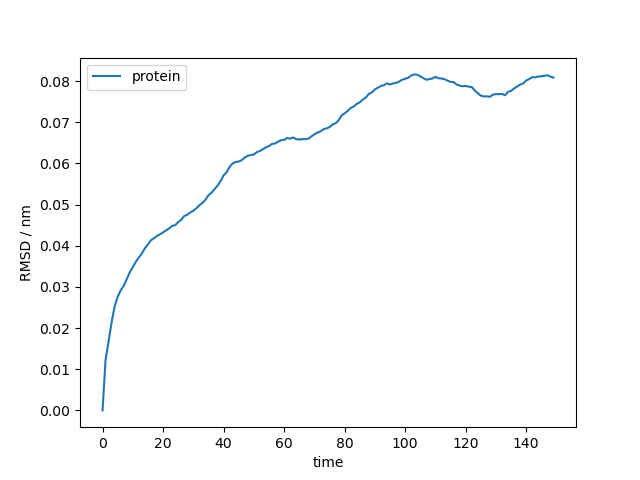

In [9]:
# make sure rmsd plot was generated
from IPython.display import Image
Image(filename=registry.get_mapped_path('fig0_215222'))

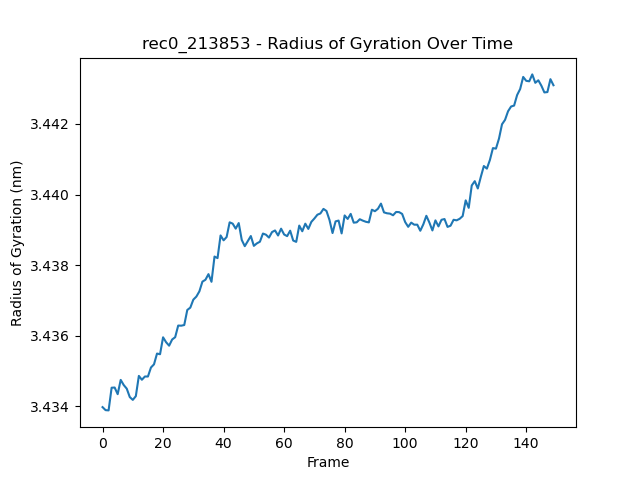

In [10]:
# make sure rgy plot was generated
from IPython.display import Image
Image(filename=registry.get_mapped_path('fig0_220446'))

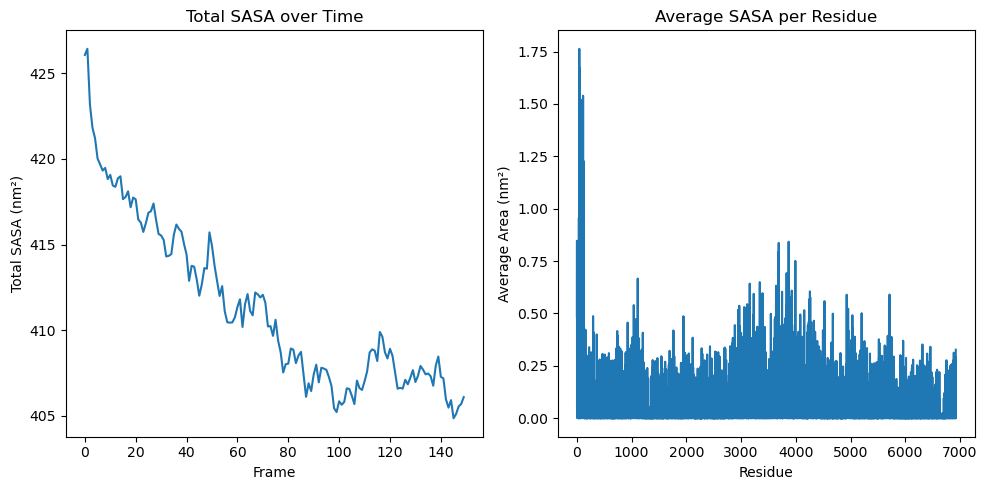

In [11]:
# make sure sasa plot was generated
from IPython.display import Image
Image(filename=registry.get_mapped_path('fig0_220441'))

In [14]:
#verify the total cost
def calculate_llm_cost(input_tokens, output_tokens, model):
    pricing_2024 = {
        "gpt-4-1106-preview": {"input": 10/1e6, "output": 30/1e6},
        "gpt-3.5-turbo-0125": {"input": 0.5/1e6, "output": 1.5/1e6},
        "gpt-4-turbo-2024-04-09": {"input": 10/1e6, "output": 30/1e6},
        "gpt-4o-2024-08-06": {"input": 5/1e6, "output": 15/1e6},
        "llama-v3p1-70b-instruct": {"input": 0.9/1e6, "output": 0.9/1e6},
        "llama-v3p1-405b-instruct": {"input": 3/1e6, "output": 3/1e6},
        "claude-3-opus": {"input": 15/1e6, "output": 75/1e6},
        "claude-3.5-sonnet": {"input": 3/1e6, "output": 15/1e6},
    }
    pricing_2025 = {
        "gpt-4-1106-preview": {"input": 10/1e6, "output": 30/1e6},
        "gpt-3.5-turbo-0125": {"input": 0.5/1e6, "output": 1.5/1e6},
        "gpt-4-turbo-2024-04-09": {"input": 10/1e6, "output": 30/1e6},
        "gpt-4o-2024-08-06": {"input": 2.5/1e6, "output": 10/1e6},
        "llama-v3p1-70b-instruct": {"input": 0.9/1e6, "output": 0.9/1e6},
        "llama-v3p1-405b-instruct": {"input": 3/1e6, "output": 3/1e6},
    }
    
    prices = pricing_2025[model]
    cost = (input_tokens * prices["input"]) + (output_tokens * prices["output"])
    return round(cost, 6)

llm_cost = calculate_llm_cost(cb.prompt_tokens, cb.completion_tokens, agent.llm.model_name)
print('Input tokens:',cb.prompt_tokens)
print('Output tokens:',cb.completion_tokens)
print('LLM costs: $',llm_cost)

Input tokens: 120585
Output tokens: 2261
LLM costs: $ 1.27368
